
# K-Means Cluster Interpretation

## Objective
Understand how to interpret clusters after applying K-Means.

## Dataset
`kmeans_interpret.csv`

## Tasks
- Apply K-Means and choose an appropriate K
- Compute mean values of each cluster
- Analyze cluster characteristics

## Questions
1. How many clusters did you choose and why?
2. Describe each cluster in terms of features.
3. What real-world meaning can you assign to each cluster?


In [1]:

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Libraries imported successfully")


Libraries imported successfully


In [2]:

# Load dataset

data = pd.read_csv("kmeans_interpret.csv")

print("First 5 rows of dataset:")
display(data.head())

print("\nDataset shape:", data.shape)


First 5 rows of dataset:


,Age,SpendingScore
0,27.483571,28.617357
1,28.238443,45.230299
2,23.829233,27.658630
3,32.896064,37.674347
4,22.652628,35.425600



Dataset shape: (300, 2)


In [ ]:

# Dataset information

print("Dataset Info:")
print(data.info())

print("\nStatistical Summary:")
display(data.describe())



## Step 1: Select Numerical Features

K-Means works with numerical values.  
If your dataset contains non-numeric columns, they are excluded here.


In [3]:

# Select numerical columns only

X = data.select_dtypes(include=[np.number]).copy()

print("Selected numerical features:")
print(list(X.columns))

print("\nFeature matrix shape:", X.shape)
display(X.head())


Selected numerical features:
['Age', 'SpendingScore']

Feature matrix shape: (300, 2)


,Age,SpendingScore
0,27.483571,28.617357
1,28.238443,45.230299
2,23.829233,27.658630
3,32.896064,37.674347
4,22.652628,35.425600



## Step 2: Standardize the Features

K-Means uses distance calculation.  
So, features should be scaled before clustering.


In [4]:

# Standardize features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully")


Data standardized successfully



## Step 3: Use Elbow Method to Choose K

The elbow method compares K values using inertia / WCSS.

- Lower inertia means points are closer to their cluster centers.
- Inertia always decreases as K increases.
- We choose the K where the decrease starts becoming slow.


In [5]:

# Elbow method for K = 1 to 10

inertia_values = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Show inertia values
elbow_df = pd.DataFrame({
    "K": list(K_range),
    "Inertia_WCSS": inertia_values
})

display(elbow_df)


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

,K,Inertia_WCSS
0,1,600.000000
1,2,293.512524
2,3,89.754675
3,4,78.163747
4,5,66.656012
5,6,57.155066
6,7,50.373266
7,8,43.794911
8,9,37.674143
9,10,34.724465


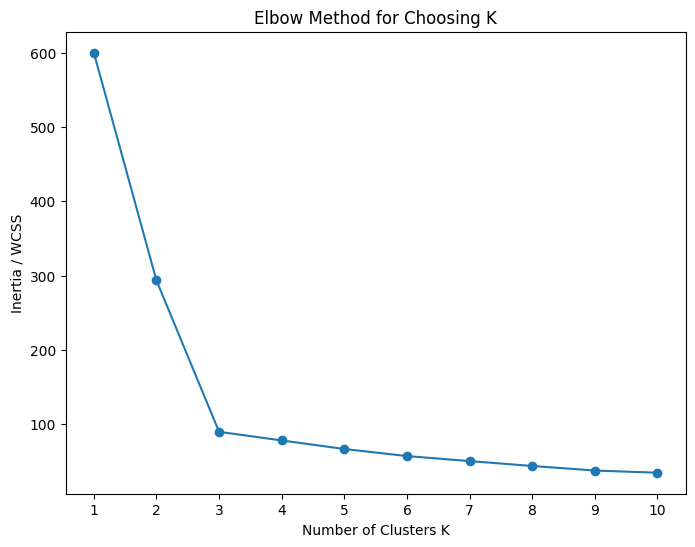

In [6]:

# Plot elbow curve

plt.figure(figsize=(8, 6))

plt.plot(
    list(K_range),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method for Choosing K")
plt.xticks(list(K_range))

plt.show()



## Step 4: Choose K

From the elbow graph, choose the point where the curve bends.

In this notebook, we use **K = 3** as a default example.  
You can change `chosen_k` after looking at the elbow graph.


In [7]:

# Choose K based on elbow graph

chosen_k = 3

print("Chosen K:", chosen_k)


Chosen K: 3


In [8]:

# Apply K-Means with chosen K

kmeans_final = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_scaled)

data["Cluster"] = clusters

print("Cluster labels:")
print(clusters[:20])

print("\nCluster counts:")
display(data["Cluster"].value_counts().sort_index())


Cluster labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]

Cluster counts:


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Cluster
0    100
1    100
2    100
Name: count, dtype: int64


## Step 5: Compute Mean Values of Each Cluster

Cluster means help us understand the character of each cluster.


In [9]:

# Cluster-wise mean values in original scale

cluster_means = data.groupby("Cluster")[X.columns].mean()

print("Cluster-wise mean values:")
display(cluster_means)


Cluster-wise mean values:


,Age,SpendingScore
Cluster,,
0,45.641244,80.434876
1,49.774813,28.737273
2,24.422179,30.340223


In [10]:

# Overall mean for comparison

overall_mean = data[X.columns].mean()

comparison_df = cluster_means.copy()

print("Overall feature mean:")
display(overall_mean.to_frame(name="Overall_Mean"))


Overall feature mean:


,Overall_Mean
Age,39.946078
SpendingScore,46.504124



## Step 6: Identify High and Low Features in Each Cluster

This helps describe each cluster in simple language.


In [11]:

# Compare cluster means against overall mean

cluster_profile = cluster_means.copy()

for feature in X.columns:
    cluster_profile[feature] = np.where(
        cluster_means[feature] > overall_mean[feature],
        "High",
        "Low"
    )

print("Cluster profile compared to overall mean:")
display(cluster_profile)


Cluster profile compared to overall mean:


,Age,SpendingScore
Cluster,,
0,High,High
1,High,Low
2,Low,Low



## Step 7: Visualize Clusters using PCA

If the dataset has more than 2 features, PCA helps us visualize clusters in 2D.


In [12]:

# Reduce data to 2D using PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained:")
print(pca.explained_variance_ratio_.sum())

display(pca_df.head())


Explained variance ratio:
[0.64414795 0.35585205]

Total variance explained:
1.0


,PC1,PC2,Cluster
0,-1.216026,-0.237748,2
1,-0.717693,-0.648024,2
2,-1.455387,-0.424673,2
3,-0.652661,-0.169736,2
4,-1.311614,-0.705698,2


In [ ]:

# Plot clusters in PCA space

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Cluster Visualization using PCA")

plt.show()



## Step 8: Create Cluster Interpretation Table

Use this table to assign meaningful names to each cluster.


In [13]:

# Create an interpretation template

interpretation = pd.DataFrame({
    "Cluster": cluster_means.index,
    "Key Characteristics": [
        "Describe based on high/low feature values" for _ in cluster_means.index
    ],
    "Possible Real-World Meaning": [
        "Assign business/domain meaning here" for _ in cluster_means.index
    ]
})

display(interpretation)


,Cluster,Key Characteristics,Possible Real-World Meaning
0,0,Describe based on high/low feature values,Assign business/domain meaning here
1,1,Describe based on high/low feature values,Assign business/domain meaning here
2,2,Describe based on high/low feature values,Assign business/domain meaning here



# Answers to Questions

## 1. How many clusters did you choose and why?

I chose **K = 3** as the default value in this notebook.

Reason:
- The elbow method is used to compare inertia for different K values.
- The best K is usually where the curve starts bending.
- If your elbow graph clearly bends at another value, update `chosen_k`.

---

## 2. Describe each cluster in terms of features

Use the cluster mean table.

Example format:

- **Cluster 0**: High in some features and low in others.
- **Cluster 1**: Lower average values compared to other clusters.
- **Cluster 2**: Higher average values compared to other clusters.

The exact description depends on the values in the cluster mean table.

---

## 3. What real-world meaning can you assign to each cluster?

Real-world meaning depends on the dataset domain.

Examples:
- In customer data:
  - Low spend, low activity customers
  - Medium spend, regular customers
  - High spend, premium customers

- In student data:
  - Low performance group
  - Average performance group
  - High performance group

- In transaction data:
  - Low-value transactions
  - Normal transactions
  - High-value or unusual transactions

Use feature averages to assign meaningful labels.
